# The profile ladder, compared

Four quality tiers behind one design path (PLAN §4, v0.3 ladder). This
notebook puts them side by side: frequency responses, the top-octave trade
each tier makes, cost in MACs/storage/latency, and quality measured through
the **actual shipping C++** via the C ABI (`ratiotap_py.py` ctypes bridge —
family convention: nothing here is a Python re-implementation except the
prototype *designs*, which mirror `tap::dsp::design_prototype` exactly and
are cross-checked against the engine by the design-spike notebook).

| tier | stopband | passband | taps down/up | role |
|---|---|---|---|---|
| `super_economy` | 70 dB | 16 kHz | 40 / 28 | voice/comms — audible top-octave shelf, half of balanced's MACs |
| `economy` (default) | 70 dB | 18 kHz | 58 / 38 | speed-first default — inaudible trade |
| `balanced` | 70 dB | 19 kHz | 78 / 44 | the pre-v0.3 default, unchanged |
| `transparent` | 120 dB | 20 kHz | 184 / 96 | pristine/offline |

Tier colors are fixed across every plot (colorblind-safe, validated:
adjacent-pair CVD ΔE ≥ 8.6); every series is also direct-labeled, so
identity never rides on color alone.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ratiotap_py import RatioConverter

# Fixed tier order and colors — identical in every figure below.
TIERS = {  # name: (passband_hz, taps_down, taps_up, atten_db, color)
    "super_economy": (16000.0,  40, 28,  70.0, "#E69F00"),
    "economy":       (18000.0,  58, 38,  70.0, "#009E73"),
    "balanced":      (19000.0,  78, 44,  70.0, "#0072B2"),
    "transparent":   (20000.0, 184, 96, 120.0, "#CC79A7"),
}
DIRS = {"down": (147, 160, 48000.0, 22050.0), "up": (160, 147, 44100.0, 24000.0)}

def kaiser_beta(a):
    if a > 50.0:
        return 0.1102 * (a - 8.7)
    if a > 21.0:
        return 0.5842 * (a - 21.0) ** 0.4 + 0.07886 * (a - 21.0)
    return 0.0

def design(L, taps, cutoff_norm, beta):
    # Mirrors tap::dsp::design_prototype + RatioTap's per-branch DC norm.
    n = L * taps
    i = np.arange(n)
    center = 0.5 * (n - 1)
    t = (i - center) / L
    u = (i - center) / center
    w = np.i0(beta * np.sqrt(np.maximum(0.0, 1.0 - u * u))) / np.i0(beta)
    h = cutoff_norm * np.sinc(cutoff_norm * t) * w
    h *= L / h.sum()
    b = h.reshape(taps, L).sum(axis=0)
    return (h.reshape(taps, L) / b).reshape(-1)

def response_db(h, L, fs, freqs, chunk=512):
    m = np.arange(len(h))
    out = np.empty(len(freqs))
    for k in range(0, len(freqs), chunk):
        f = np.asarray(freqs[k:k + chunk])[:, None]
        out[k:k + chunk] = 20 * np.log10(
            np.abs(np.exp(-2j * np.pi * f * m / (L * fs)) @ h) / L)
    return out

H = {}  # (dir, tier) -> prototype
for d, (L, M, fs, stop) in DIRS.items():
    for name, (pas, td, tu, atten, _c) in TIERS.items():
        taps = td if d == "down" else tu
        H[d, name] = design(L, taps, (pas + stop) / fs, kaiser_beta(atten))

def label_at_crossing(ax, f, r, level, name, color, dx=-0.15, ha="right"):
    # Anchor a series label where its own curve crosses `level` dB — each
    # tier crosses at a different frequency, so labels never collide.
    i = int(np.argmax(r <= level))
    ax.annotate(name, xy=(f[i] / 1e3, r[i]), xytext=(f[i] / 1e3 + dx, r[i]),
                color=color, fontsize=9, fontweight="bold", ha=ha, va="center")

def tier_legend(ax):
    ax.legend([plt.Line2D([], [], color=TIERS[n][4], lw=2) for n in TIERS],
              list(TIERS), fontsize=8, frameon=False, loc="lower left")

print(f"{len(H)} designs built")

8 designs built


## Frequency response: the whole ladder

Both directions, all four tiers. Every 70 dB tier holds the same stopband
contract — what changes is *where the passband ends* and how steep the
transition must therefore be (which is exactly what the tap counts buy).

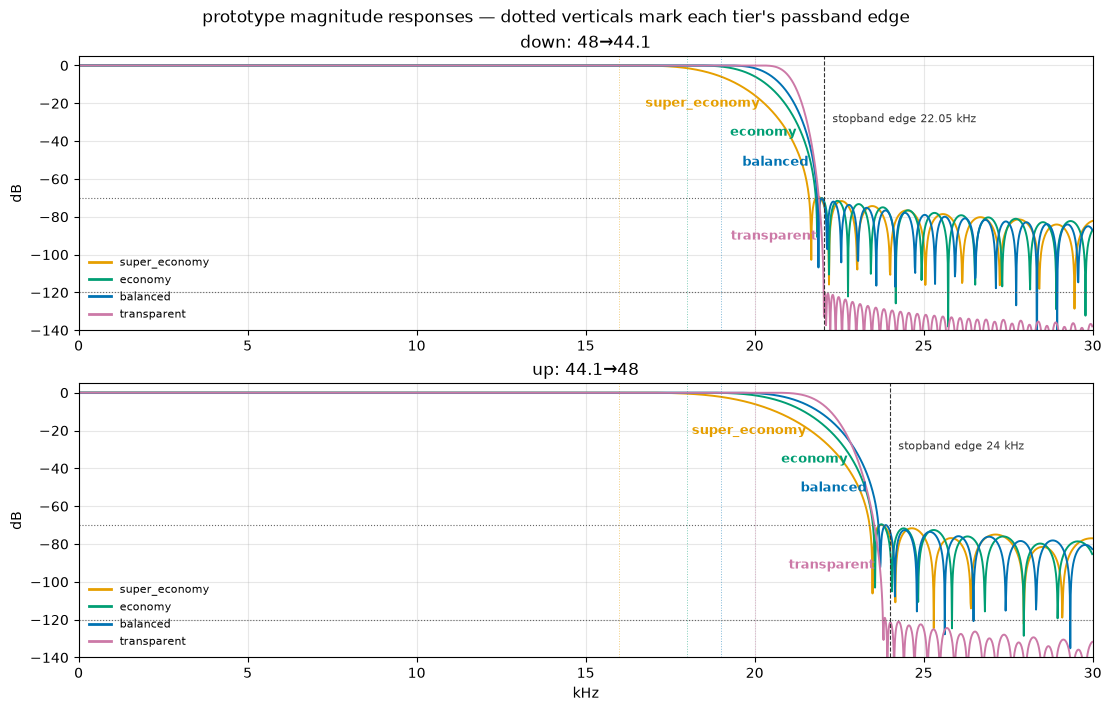

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True)
LEVELS = {"super_economy": -20.0, "economy": -35.0, "balanced": -50.0, "transparent": -90.0}
for ax, d in zip(axes, ("down", "up")):
    L, M, fs, stop = DIRS[d]
    f = np.arange(0.0, 30000.0, 12.5)
    for name, (pas, td, tu, atten, color) in TIERS.items():
        r = response_db(H[d, name], L, fs, f)
        ax.plot(f / 1e3, r, color=color, lw=1.4)
        label_at_crossing(ax, f, r, LEVELS[name], name, color)
        ax.axvline(pas / 1e3, color=color, ls=":", lw=0.7, alpha=0.5)
    ax.axhline(-70, color="0.4", ls=":", lw=0.8)
    ax.axhline(-120, color="0.4", ls=":", lw=0.8)
    ax.axvline(stop / 1e3, color="0.2", ls="--", lw=0.8)
    ax.text(stop / 1e3 + 0.25, -30, f"stopband edge {stop/1e3:g} kHz",
            fontsize=8, color="0.2")
    ax.set_ylim(-140, 5)
    ax.set_xlim(0, 30)
    ax.set_ylabel("dB")
    ax.grid(alpha=0.3)
    tier_legend(ax)
    ax.set_title(f"{d}: 48\u219244.1" if d == "down" else f"{d}: 44.1\u219248")
axes[1].set_xlabel("kHz")
fig.suptitle("prototype magnitude responses \u2014 dotted verticals mark each tier's passband edge")
plt.show()

## The top octave — the decision plot

This is the only place the 70 dB tiers differ audibly: where the shelf into
the transition band begins. `economy` gives up 18–19 kHz (inaudible for
almost all listeners and program material); `super_economy` gives up
16–19 kHz, which *is* audible to young ears on wideband material — that is
why it is opt-in by name and never a default.

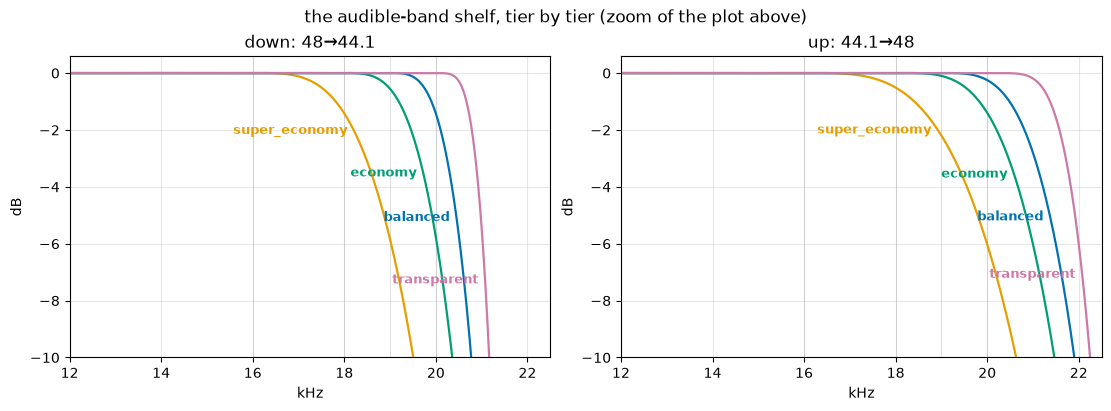

super_economy down shelf: -1.42 dB @ 18 kHz, -5.85 dB @ 19 kHz


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ZLEVELS = {"super_economy": -2.0, "economy": -3.5, "balanced": -5.0, "transparent": -7.0}
for ax, d in zip(axes, ("down", "up")):
    L, M, fs, stop = DIRS[d]
    f = np.arange(12000.0, 22500.0, 12.5)
    for name, (pas, td, tu, atten, color) in TIERS.items():
        r = response_db(H[d, name], L, fs, f)
        ax.plot(f / 1e3, r, color=color, lw=1.6)
        label_at_crossing(ax, f, r, ZLEVELS[name], name, color)
    for probe in (16.0, 18.0, 19.0, 20.0):
        ax.axvline(probe, color="0.85", lw=0.6, zorder=0)
    ax.set_ylim(-10, 0.6)
    ax.set_xlim(12, 22.5)
    ax.grid(alpha=0.3)
    ax.set_ylabel("dB")
    ax.set_xlabel("kHz")
    ax.set_title("down: 48\u219244.1" if d == "down" else "up: 44.1\u219248")
fig.suptitle("the audible-band shelf, tier by tier (zoom of the plot above)")
plt.show()
# The numbers quoted in PLAN section 4, asserted from the same designs:
r18 = response_db(H["down", "super_economy"], 147, 48000.0, np.array([18000.0]))[0]
r19 = response_db(H["down", "super_economy"], 147, 48000.0, np.array([19000.0]))[0]
print(f"super_economy down shelf: {r18:+.2f} dB @ 18 kHz, {r19:+.2f} dB @ 19 kHz")
assert -1.6 < r18 < -1.2 and -6.3 < r19 < -5.5

## Measured through the shipping engine

Swept sine probes 48 → 44.1 through the C ABI, fit at the output rate.
Every tier must be flat (±0.02 dB) inside **its own** passband; the shelf
begins exactly where the design says. This is the engine, not the design
math.

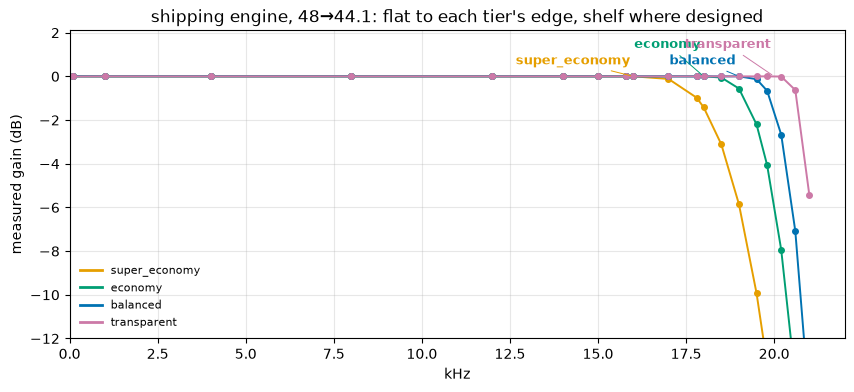

all tiers flat within ±0.02 dB inside their own passbands


In [4]:
fs_in, fs_out = 48000.0, 44100.0

def measured_gain_db(profile, freq_hz):
    c = RatioConverter(direction="down", profile=profile)
    n = 1 << 15
    x = (0.5 * np.sin(2 * np.pi * freq_hz / fs_in * np.arange(n))).astype(np.float32)
    y = c.process(x)[int(c.latency_input_frames) * 2:]
    w = 2 * np.pi * freq_hz / fs_out
    a = 2 / len(y) * np.abs(np.sum(y * np.exp(-1j * w * np.arange(len(y)))))
    return 20 * np.log10(a / 0.5)

freqs = np.array([100, 1000, 4000, 8000, 12000, 14000, 15000, 15800, 16000,
                  17000, 17800, 18000, 18500, 19000, 19500, 19800, 20200, 20600, 21000])
fig, ax = plt.subplots(figsize=(10, 4))
for k, (name, (pas, td, tu, atten, color)) in enumerate(TIERS.items()):
    g = np.array([measured_gain_db(name, fq) for fq in freqs])
    ax.plot(freqs / 1e3, g, "o-", color=color, lw=1.4, ms=4)
    # Label above each tier's own passband edge; alternate heights so the
    # 1-kHz-apart economy/balanced pair cannot collide.
    ax.annotate(name, xy=(pas / 1e3, 0.0), xytext=(pas / 1e3 - 0.1, 0.55 + 0.75 * (k % 2)),
                color=color, fontsize=9, fontweight="bold", ha="right",
                arrowprops=dict(arrowstyle="-", color=color, lw=0.7))
    inside = freqs <= pas
    assert np.all(np.abs(g[inside]) < 0.02), name  # flat in own passband
ax.set_ylim(-12, 2.1)
ax.set_xlim(0, 22)
ax.grid(alpha=0.3)
tier_legend(ax)
ax.set_xlabel("kHz")
ax.set_ylabel("measured gain (dB)")
ax.set_title("shipping engine, 48\u219244.1: flat to each tier's edge, shelf where designed")
plt.show()
print("all tiers flat within \u00b10.02 dB inside their own passbands")

## Program material through each tier

The demo notebook's program — 997 Hz + 6 kHz + 17.5 kHz tones with a
hostile 23 kHz ultrasonic component — down-converted through all four
tiers. The two spurious species behave exactly as the acceptance contract
says: the decimation **alias** of 23 kHz folds to 21.1 kHz (ultrasonic by
arithmetic, bounded by the stopband), and the upsampling **image** at
25 kHz folds in-band to 19.1 kHz at stopband depth. Note transparent's
−120 dB floor, and that every 70 dB tier keeps the audible band clean.

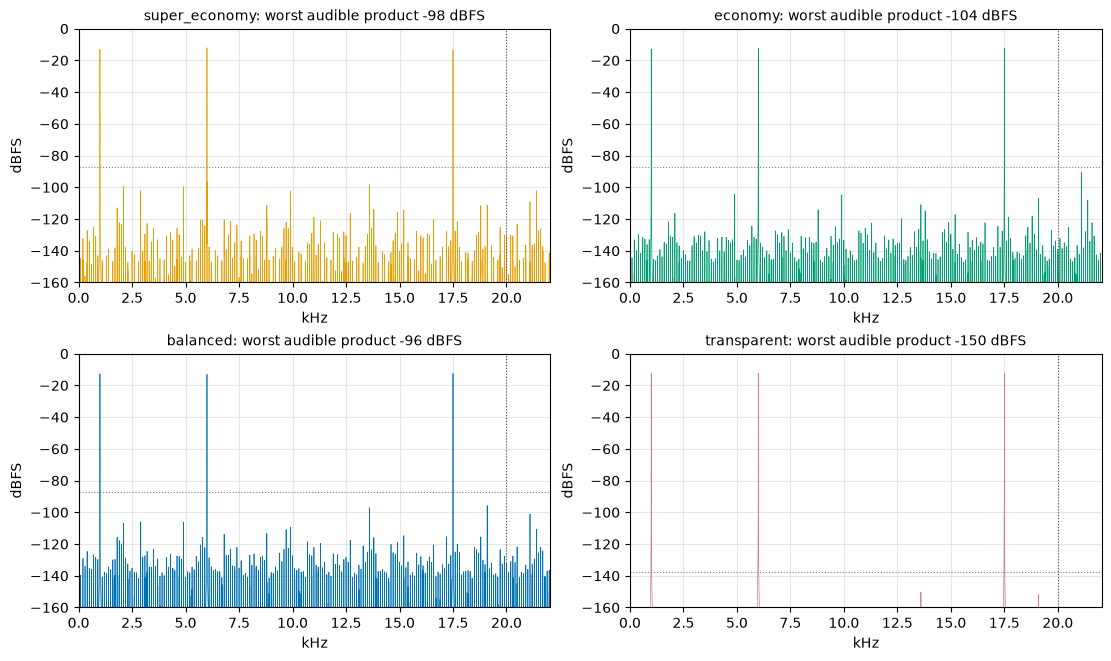

In [5]:
n_in = 1 << 17
t = np.arange(n_in) / fs_in
tones = [(997.0, 0.25), (6000.0, 0.25), (17500.0, 0.25), (23000.0, 0.15)]
x = sum(a * np.sin(2 * np.pi * f0 * t) for f0, a in tones).astype(np.float32)

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True)
for ax, (name, (pas, td, tu, atten, color)) in zip(axes.flat, TIERS.items()):
    c = RatioConverter(direction="down", profile=name)
    y = np.concatenate([c.process(x), c.flush()])[int(c.latency_input_frames) * 2:]
    win = np.blackman(len(y))
    spec = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(y * win)) / (win.sum() / 2), 1e-12))
    fbin = np.fft.rfftfreq(len(y), 1 / fs_out)
    ax.plot(fbin / 1e3, spec, lw=0.5, color=color)
    ax.axvline(20, color="0.3", ls=":", lw=0.8)
    ax.axhline(-16.5 - (atten + 1), color="0.5", ls=":", lw=0.8)
    ax.set_ylim(-160, 0)
    ax.set_xlim(0, 22.05)
    ax.grid(alpha=0.3)
    tone_mask = np.zeros(len(fbin), bool)
    for f0, _ in tones[:3]:
        tone_mask |= np.abs(fbin - f0) < 80
    audible = ~tone_mask & (fbin > 200) & (fbin < 20000)
    worst = spec[audible].max()
    ax.set_title(f"{name}: worst audible product {worst:.0f} dBFS", fontsize=10)
    ax.set_ylabel("dBFS")
    ax.set_xlabel("kHz")
plt.show()

## Cost: MACs, storage, latency

One tier, one color, three costs. Solid bars are the down direction
(48 → 44.1, the expensive one), hatched bars are up. Storage is the
shipping symmetry-halved table (`ceil(L/2)` rows, f32; Q15 halves it
again).

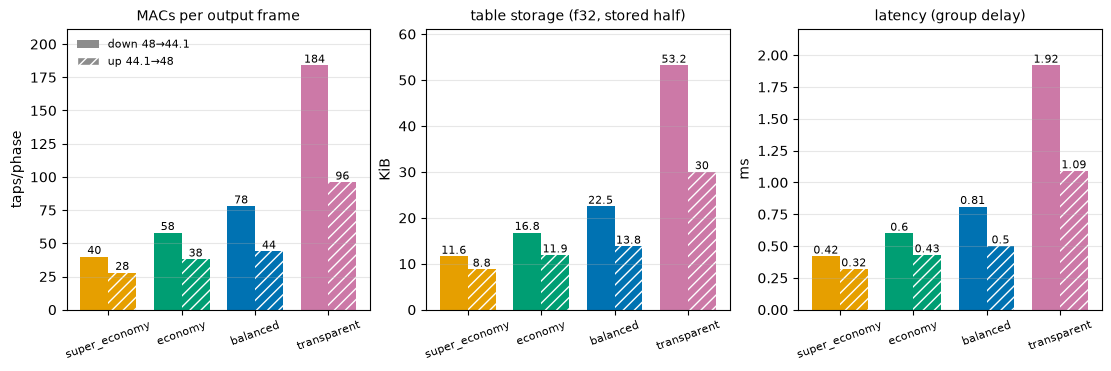

In [6]:
names = list(TIERS)
xd = np.arange(len(names))
W = 0.38
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
def bars(ax, vals_down, vals_up, title, unit):
    for i, name in enumerate(names):
        color = TIERS[name][4]
        ax.bar(i - W / 2, vals_down[i], W, color=color)
        ax.bar(i + W / 2, vals_up[i], W, color=color, hatch="///",
               edgecolor="white", lw=0)
        for dx, v in ((-W / 2, vals_down[i]), (W / 2, vals_up[i])):
            ax.text(i + dx, v, f"{v:g}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xd, names, rotation=20, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(unit)
    ax.grid(alpha=0.3, axis="y")
    ax.margins(y=0.15)
bars(axes[0], [TIERS[n][1] for n in names], [TIERS[n][2] for n in names],
     "MACs per output frame", "taps/phase")
bars(axes[1], [round(74 * TIERS[n][1] * 4 / 1024, 1) for n in names],
     [round(80 * TIERS[n][2] * 4 / 1024, 1) for n in names],
     "table storage (f32, stored half)", "KiB")
bars(axes[2], [round(TIERS[n][1] / 2 / 48000 * 1e3, 2) for n in names],
     [round(TIERS[n][2] / 2 / 44100 * 1e3, 2) for n in names],
     "latency (group delay)", "ms")
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, fc="0.55"),
                        plt.Rectangle((0, 0), 1, 1, fc="0.55", hatch="///", ec="white")],
               labels=["down 48\u219244.1", "up 44.1\u219248"],
               loc="upper left", fontsize=8, frameon=False)
plt.show()

## Quality vs cost, measured

997 Hz half-scale through the shipping engine (float, down direction):
fit the fundamental, everything left is the residual. The 70 dB tiers all
sit on their imaging floors in the high 80s/low 90s; transparent buys
~25 dB more for 3–4.6× the MACs. (Q15 numbers, pinned by the C++ suite,
tell the embedded story: the *format* floors near 76 dB regardless of
tier — which is why economy-class tiers are the right Q15 pairing.)

super_economy   40 MACs/out  SNR 85.3 dB
economy         58 MACs/out  SNR 91.3 dB
balanced        78 MACs/out  SNR 89.2 dB
transparent    184 MACs/out  SNR 144.9 dB


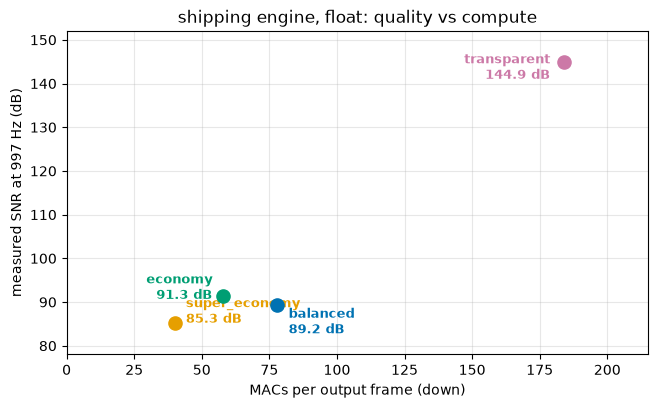

In [7]:
def measured_snr_db(profile, freq_hz=997.0):
    c = RatioConverter(direction="down", profile=profile)
    n = 1 << 16
    x = (0.5 * np.sin(2 * np.pi * freq_hz / fs_in * np.arange(n))).astype(np.float32)
    y = c.process(x)[int(c.latency_input_frames) * 2:].astype(np.float64)
    i = np.arange(len(y))
    w = 2 * np.pi * freq_hz / fs_out
    A = np.column_stack([np.sin(w * i), np.cos(w * i)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ coef
    return 10 * np.log10((coef @ coef) / 2 / np.mean(resid ** 2))

OFFS = {"super_economy": (8, 8, "left"), "economy": (-8, 6, "right"),
        "balanced": (8, -12, "left"), "transparent": (-10, -4, "right")}
plt.figure(figsize=(7.5, 4.2))
for name, (pas, td, tu, atten, color) in TIERS.items():
    snr = measured_snr_db(name)
    dx, dy, ha = OFFS[name]
    plt.scatter(td, snr, s=90, color=color, zorder=3)
    plt.annotate(f"{name}\n{snr:.1f} dB", xy=(td, snr), xytext=(dx, dy),
                 textcoords="offset points", ha=ha, va="center",
                 color=color, fontsize=9, fontweight="bold")
    print(f"{name:14s} {td:3d} MACs/out  SNR {snr:.1f} dB")
plt.xlabel("MACs per output frame (down)")
plt.ylabel("measured SNR at 997 Hz (dB)")
plt.title("shipping engine, float: quality vs compute")
plt.grid(alpha=0.3)
plt.xlim(0, 215)
plt.ylim(78, 152)
plt.show()

## Summary

| tier | MACs down/up | storage f32 (stored) | latency down | measured 997 Hz float | Q15 997 Hz (C++ suite) | the trade |
|---|---|---|---|---|---|---|
| `super_economy` | 40 / 28 | 11.6 / 8.8 KiB | 0.42 ms | ~85 dB | 77.7 dB | audible top-octave shelf (−1.4 dB @ 18 k, −5.9 dB @ 19 k down) |
| `economy` (default) | 58 / 38 | 16.8 / 11.9 KiB | 0.60 ms | ~91 dB | 76.5 dB | 18–19 kHz into the transition — inaudible |
| `balanced` | 78 / 44 | 22.5 / 13.8 KiB | 0.81 ms | ~89 dB | 76.1 dB | none vs the pre-v0.3 default (it *is* that design) |
| `transparent` | 184 / 96 | 53.2 / 30.0 KiB | 1.92 ms | ~115+ dB | 72.8 dB | 2–5× the compute; Q15 *worse* (coefficient noise stacks with taps) |

Guidance: `economy` unless you have a reason; `balanced` when the
18–19 kHz shelf must stay flat; `transparent` for pristine float/Q31
offline work; `super_economy` for voice/comms/Bluetooth-class links where
the top octave is already gone — in Q15 it is *quieter* than transparent
and a quarter of balanced's compute.